## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import time
import json
from tqdm.auto import tqdm

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"[MOBILENETV3-02-TRAINING] Libraries loaded")
print(f"[MOBILENETV3-02-TRAINING] Device: {device}")
print(f"[MOBILENETV3-02-TRAINING] PyTorch version: {torch.__version__}")

[MOBILENETV3-02-TRAINING] Libraries loaded
[MOBILENETV3-02-TRAINING] Device: cuda
[MOBILENETV3-02-TRAINING] PyTorch version: 2.6.0+cu124


## Configuration

In [2]:
# Input paths (from 01-Preprocessing-Step)
INPUT_DIR = '/kaggle/input/mobilenetv3-01-preprocessing-output'

# Fallback for local testing
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = './mobilenetv3-01-preprocessing-output'

# Dataset base path
DATASET_BASE_PATH = '/kaggle/input/dataset-sampah'

if not os.path.exists(DATASET_BASE_PATH):
    DATASET_BASE_PATH = input("Enter dataset path: ").strip()

# Output directory
OUTPUT_DIR = './mobilenetv3-02-training-output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class configuration
CLASSES = ['Organik', 'Anorganik', 'Lainnya']
NUM_CLASSES = len(CLASSES)

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

print(f"[MOBILENETV3-02-TRAINING] Input directory: {INPUT_DIR}")
print(f"[MOBILENETV3-02-TRAINING] Dataset path: {DATASET_BASE_PATH}")
print(f"[MOBILENETV3-02-TRAINING] Output directory: {OUTPUT_DIR}")
print(f"[MOBILENETV3-02-TRAINING] Classes: {CLASSES}")
print(f"\nTraining Configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")

[MOBILENETV3-02-TRAINING] Input directory: /kaggle/input/mobilenetv3-01-preprocessing-output
[MOBILENETV3-02-TRAINING] Dataset path: /kaggle/input/dataset-sampah
[MOBILENETV3-02-TRAINING] Output directory: ./mobilenetv3-02-training-output
[MOBILENETV3-02-TRAINING] Classes: ['Organik', 'Anorganik', 'Lainnya']

Training Configuration:
  Batch size: 32
  Epochs: 20
  Learning rate: 0.001
  Weight decay: 0.0001


## Load CSV Files from 01-Preprocessing

In [3]:
print("[MOBILENETV3-02-TRAINING] Loading CSV files from 01-Preprocessing...")

train_df = pd.read_csv(f'{INPUT_DIR}/train_dataset.csv')
val_df = pd.read_csv(f'{INPUT_DIR}/val_dataset.csv')
test_df = pd.read_csv(f'{INPUT_DIR}/test_dataset.csv')

print(f"[MOBILENETV3-02-TRAINING] CSV files loaded:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val:   {len(val_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")

print(f"\nDataFrame preview:")
print(train_df.head())

[MOBILENETV3-02-TRAINING] Loading CSV files from 01-Preprocessing...
[MOBILENETV3-02-TRAINING] CSV files loaded:
  Train: 12,600 samples
  Val:   2,700 samples
  Test:  2,700 samples

DataFrame preview:
                                          image_path class_name  class_idx
0  /kaggle/input/dataset-sampah/Anorganik/Anorgan...  Anorganik          1
1  /kaggle/input/dataset-sampah/Anorganik/Anorgan...  Anorganik          1
2  /kaggle/input/dataset-sampah/Organik/Organik49...    Organik          0
3  /kaggle/input/dataset-sampah/Anorganik/Anorgan...  Anorganik          1
4  /kaggle/input/dataset-sampah/Lainnya/Lainnya43...    Lainnya          2


## Image Transforms (PyTorch Best Practice)

In [4]:
# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transform WITH augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),  # Auto-converts [0-255] to [0-1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/Test transform WITHOUT augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Auto-converts [0-255] to [0-1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("[MOBILENETV3-02-TRAINING] Transformations configured:")
print("  Train transform:")
print("    1. Resize(224, 224)")
print("    2. RandomHorizontalFlip(p=0.5)")
print("    3. RandomRotation(±15°)")
print("    4. ColorJitter(brightness/contrast/saturation/hue)")
print("    5. ToTensor() → [0-255] to [0-1]")
print("    6. Normalize(ImageNet mean/std)")
print("\n  Val/Test transform:")
print("    1. Resize(224, 224)")
print("    2. ToTensor() → [0-255] to [0-1]")
print("    3. Normalize(ImageNet mean/std)")
print("    (NO augmentation!)")

[MOBILENETV3-02-TRAINING] Transformations configured:
  Train transform:
    1. Resize(224, 224)
    2. RandomHorizontalFlip(p=0.5)
    3. RandomRotation(±15°)
    4. ColorJitter(brightness/contrast/saturation/hue)
    5. ToTensor() → [0-255] to [0-1]
    6. Normalize(ImageNet mean/std)

  Val/Test transform:
    1. Resize(224, 224)
    2. ToTensor() → [0-255] to [0-1]
    3. Normalize(ImageNet mean/std)
    (NO augmentation!)


## Custom Dataset Class

In [5]:
class WasteDataset(Dataset):
    """
    Custom dataset untuk load images dari CSV paths.
    Images di-load on-the-fly, TIDAK di-cache!
    """
    def __init__(self, df, dataset_base_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.dataset_base_path = dataset_base_path
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image from path
        img_path = row['image_path']
        
        # Handle path (Kaggle vs local)
        if not os.path.exists(img_path):
            # Try relative path from dataset_base_path
            class_name = row['class_name']
            filename = os.path.basename(img_path)
            img_path = os.path.join(self.dataset_base_path, class_name, filename)
        
        # Load and convert to RGB
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = row['class_idx']
        
        return image, label

print("[MOBILENETV3-02-TRAINING] WasteDataset class defined")
print("  Features:")
print("    - Load images on-the-fly (tidak di-cache)")
print("    - Augmentasi realtime saat __getitem__()")
print("    - Support Kaggle + local paths")

[MOBILENETV3-02-TRAINING] WasteDataset class defined
  Features:
    - Load images on-the-fly (tidak di-cache)
    - Augmentasi realtime saat __getitem__()
    - Support Kaggle + local paths


## Create DataLoaders

In [6]:
print("[MOBILENETV3-02-TRAINING] Creating DataLoaders...")

# Create datasets
train_dataset = WasteDataset(train_df, DATASET_BASE_PATH, transform=train_transform)
val_dataset = WasteDataset(val_df, DATASET_BASE_PATH, transform=val_test_transform)
test_dataset = WasteDataset(test_df, DATASET_BASE_PATH, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"[MOBILENETV3-02-TRAINING] DataLoaders created:")
print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} samples)")
print(f"  Val:   {len(val_loader)} batches ({len(val_dataset)} samples)")
print(f"  Test:  {len(test_loader)} batches ({len(test_dataset)} samples)")

[MOBILENETV3-02-TRAINING] Creating DataLoaders...
[MOBILENETV3-02-TRAINING] DataLoaders created:
  Train: 394 batches (12600 samples)
  Val:   85 batches (2700 samples)
  Test:  85 batches (2700 samples)


## MobileNetV3 Model with Custom Classifier

In [7]:
class MobileNetV3Classifier(nn.Module):
    """
    MobileNetV3-Large dengan custom classifier untuk 3 classes.
    Menggunakan pretrained weights dari ImageNet.
    """
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        
        # Load pre-trained MobileNetV3-Large
        self.mobilenet = models.mobilenet_v3_large(pretrained=pretrained)
        
        # Replace classifier
        # Original: Linear(960, 1000)
        # New: Linear(960, num_classes)
        in_features = self.mobilenet.classifier[3].in_features
        
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        return self.mobilenet(x)

# Initialize model
print("[MOBILENETV3-02-TRAINING] Loading MobileNetV3-Large...")
model = MobileNetV3Classifier(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"[MOBILENETV3-02-TRAINING] MobileNetV3 loaded:")
print(f"  Architecture: MobileNetV3-Large")
print(f"  Pretrained: ImageNet")
print(f"  Num classes: {NUM_CLASSES}")
print(f"  Device: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

[MOBILENETV3-02-TRAINING] Loading MobileNetV3-Large...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 140MB/s] 


[MOBILENETV3-02-TRAINING] MobileNetV3 loaded:
  Architecture: MobileNetV3-Large
  Pretrained: ImageNet
  Num classes: 3
  Device: cuda
  Total parameters: 4,205,875
  Trainable parameters: 4,205,875


## Loss Function & Optimizer

In [8]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam with weight decay)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler (reduce on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print("[MOBILENETV3-02-TRAINING] Training setup:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

[MOBILENETV3-02-TRAINING] Training setup:
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Training & Validation Functions

In [9]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train for one epoch.
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """
    Validate for one epoch.
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

print("[MOBILENETV3-02-TRAINING] Training functions ready")

[MOBILENETV3-02-TRAINING] Training functions ready


## Train Model

In [10]:
print("[MOBILENETV3-02-TRAINING] Starting training...")
print("="*60)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    epoch_time = time.time() - epoch_start
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Time: {epoch_time:.2f}s")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_mobilenetv3_model.pth')
        print(f"✓ Best model saved (Val Acc: {val_acc:.4f})")

total_time = time.time() - start_time

print("\n" + "="*60)
print("[MOBILENETV3-02-TRAINING] Training Complete!")
print(f"  Total time: {total_time:.2f}s ({total_time/60:.1f} min)")
print(f"  Best Val Acc: {best_val_acc:.4f} (Epoch {best_epoch})")

[MOBILENETV3-02-TRAINING] Starting training...

Epoch 1/20
----------------------------------------


Training:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Loss: 0.2575 | Train Acc: 0.9033
Val Loss:   0.3404 | Val Acc:   0.9311
Time: 138.02s
✓ Best model saved (Val Acc: 0.9311)

Epoch 2/20
----------------------------------------


Training:   0%|          | 0/394 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Loss: 0.0236 | Train Acc: 0.9919
Val Loss:   0.0874 | Val Acc:   0.9778
Time: 115.70s
✓ Best model saved (Val Acc: 0.9778)

Epoch 20/20
----------------------------------------


Training:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Loss: 0.0172 | Train Acc: 0.9933
Val Loss:   0.1113 | Val Acc:   0.9715
Time: 113.25s

[MOBILENETV3-02-TRAINING] Training Complete!
  Total time: 2291.68s (38.2 min)
  Best Val Acc: 0.9778 (Epoch 19)


## Plot Training History

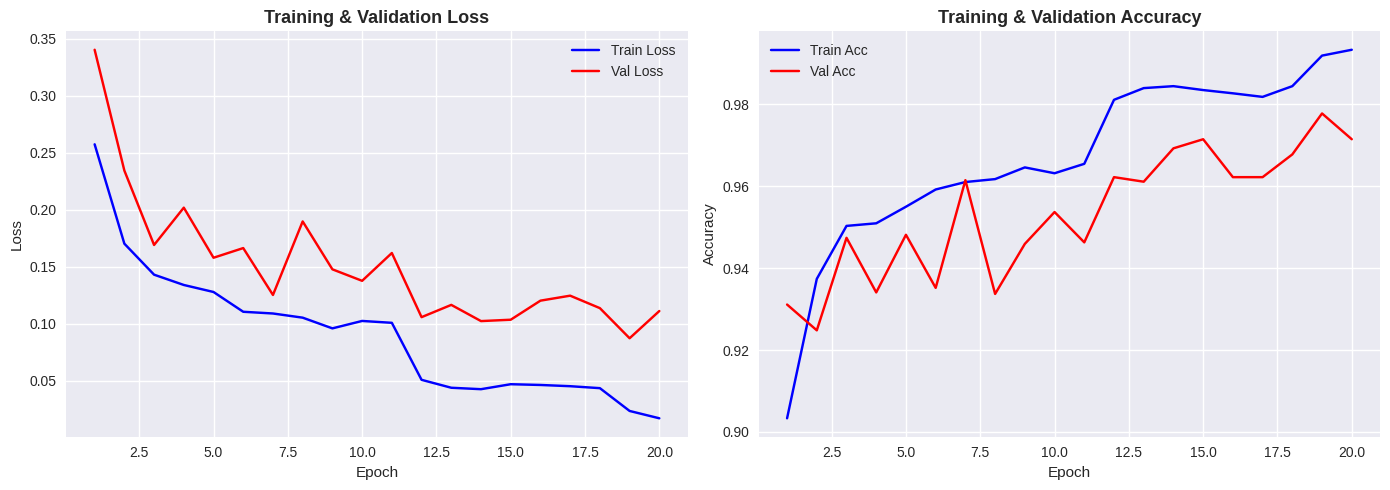

[MOBILENETV3-02-TRAINING] Training history saved to ./mobilenetv3-02-training-output/training_history.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[MOBILENETV3-02-TRAINING] Training history saved to {OUTPUT_DIR}/training_history.png")

## Load Best Model & Evaluate on Test Set

In [12]:
print("\n[MOBILENETV3-02-TRAINING] Loading best model for test evaluation...")

# Load best weights
model.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_mobilenetv3_model.pth'))
model.eval()

print(f"[MOBILENETV3-02-TRAINING] Best model loaded (from epoch {best_epoch})")

# Evaluate on test set
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)

print(f"\n[MOBILENETV3-02-TRAINING] Test Set Performance:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Acc:  {test_acc:.4f} ({test_acc*100:.2f}%)")


[MOBILENETV3-02-TRAINING] Loading best model for test evaluation...
[MOBILENETV3-02-TRAINING] Best model loaded (from epoch 19)


Validation:   0%|          | 0/85 [00:00<?, ?it/s]


[MOBILENETV3-02-TRAINING] Test Set Performance:
  Test Loss: 0.0797
  Test Acc:  0.9744 (97.44%)


## Save Training Results

In [13]:
print(f"\n[MOBILENETV3-02-TRAINING] Saving training results to: {OUTPUT_DIR}")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(f'{OUTPUT_DIR}/training_history.csv', index=False)
print(f"  ✓ training_history.csv")

# Save training metadata
training_metadata = {
    'model': 'MobileNetV3-Large',
    'num_classes': NUM_CLASSES,
    'classes': CLASSES,
    'pretrained': True,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'optimizer': 'Adam',
    'scheduler': 'ReduceLROnPlateau',
    'best_epoch': best_epoch,
    'best_val_acc': float(best_val_acc),
    'test_acc': float(test_acc),
    'test_loss': float(test_loss),
    'total_training_time': float(total_time),
    'device': str(device)
}

with open(f'{OUTPUT_DIR}/training_metadata.json', 'w') as f:
    json.dump(training_metadata, f, indent=2)

print(f"  ✓ training_metadata.json")
print(f"  ✓ best_mobilenetv3_model.pth ({os.path.getsize(f'{OUTPUT_DIR}/best_mobilenetv3_model.pth') / (1024*1024):.2f} MB)")

# List all saved files
print(f"\n[MOBILENETV3-02-TRAINING] All files saved:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    file_path = os.path.join(OUTPUT_DIR, file)
    if os.path.isfile(file_path):
        file_size = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {file} ({file_size:.2f} MB)")


[MOBILENETV3-02-TRAINING] Saving training results to: ./mobilenetv3-02-training-output
  ✓ training_history.csv
  ✓ training_metadata.json
  ✓ best_mobilenetv3_model.pth (16.25 MB)

[MOBILENETV3-02-TRAINING] All files saved:
  best_mobilenetv3_model.pth (16.25 MB)
  training_history.csv (0.00 MB)
  training_history.png (0.12 MB)
  training_metadata.json (0.00 MB)


## Training Summary

In [14]:
summary = f"""
========================================
MOBILENETV3 DIRECT - 02. TRAINING SUMMARY - JakOlah
========================================

Model Architecture:
  Base model: MobileNetV3-Large (pretrained on ImageNet)
  Custom classifier: Linear(960 → {NUM_CLASSES})
  Total parameters: {total_params:,}
  Trainable parameters: {trainable_params:,}

Training Configuration:
  Batch size: {BATCH_SIZE}
  Epochs: {NUM_EPOCHS}
  Learning rate: {LEARNING_RATE}
  Weight decay: {WEIGHT_DECAY}
  Optimizer: Adam
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
  Loss function: CrossEntropyLoss

Data Augmentation:
  Train: RandomHorizontalFlip, RandomRotation, ColorJitter
  Val/Test: No augmentation (Resize + Normalize only)

Dataset:
  Train: {len(train_dataset):,} samples
  Val:   {len(val_dataset):,} samples
  Test:  {len(test_dataset):,} samples

Training Results:
  Best epoch: {best_epoch}/{NUM_EPOCHS}
  Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
  Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)
  Total training time: {total_time:.2f}s ({total_time/60:.1f} min)

Output Files:
  ✓ best_mobilenetv3_model.pth (PyTorch state_dict)
  ✓ training_history.csv
  ✓ training_history.png
  ✓ training_metadata.json

Pipeline Comparison:
  OLD (SVM): MobileNetV3 (frozen) → Feature extraction → SVM
  NEW (Direct): MobileNetV3 (fine-tuned) → Direct classification

Key Advantages:
  1. End-to-end learning (gradient flows through entire network)
  2. Better feature adaptation to waste classification task
  3. Direct probability outputs (no need for SVM calibration)
  4. Simpler deployment (single PyTorch model)

Production Deployment:
  1. Load model: model = MobileNetV3Classifier(num_classes={NUM_CLASSES})
  2. Load weights: model.load_state_dict(torch.load('best_mobilenetv3_model.pth'))
  3. Inference: predictions = model(preprocessed_image)

========================================
NEXT STEP: Run mobilenetv3-03-evaluation-step.ipynb
========================================
"""

print(summary)

with open(f'{OUTPUT_DIR}/training_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print(f"[MOBILENETV3-02-TRAINING] Summary saved to {OUTPUT_DIR}/training_summary.md")
print(f"[MOBILENETV3-02-TRAINING] ✅ COMPLETED")


MOBILENETV3 DIRECT - 02. TRAINING SUMMARY - JakOlah

Model Architecture:
  Base model: MobileNetV3-Large (pretrained on ImageNet)
  Custom classifier: Linear(960 → 3)
  Total parameters: 4,205,875
  Trainable parameters: 4,205,875

Training Configuration:
  Batch size: 32
  Epochs: 20
  Learning rate: 0.001
  Weight decay: 0.0001
  Optimizer: Adam
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
  Loss function: CrossEntropyLoss

Data Augmentation:
  Train: RandomHorizontalFlip, RandomRotation, ColorJitter
  Val/Test: No augmentation (Resize + Normalize only)

Dataset:
  Train: 12,600 samples
  Val:   2,700 samples
  Test:  2,700 samples

Training Results:
  Best epoch: 19/20
  Best val accuracy: 0.9778 (97.78%)
  Test accuracy: 0.9744 (97.44%)
  Total training time: 2291.68s (38.2 min)

Output Files:
  ✓ best_mobilenetv3_model.pth (PyTorch state_dict)
  ✓ training_history.csv
  ✓ training_history.png
  ✓ training_metadata.json

Pipeline Comparison:
  OLD (SVM): MobileNetV3 (fr

## Download Output (Kaggle)

In [15]:
import shutil

# Create zip file of all outputs
zip_filename = 'mobilenetv3-02-training-output'
shutil.make_archive(zip_filename, 'zip', OUTPUT_DIR)

print(f"[MOBILENETV3-02-TRAINING] Output zipped to: {zip_filename}.zip")
print(f"  File size: {os.path.getsize(f'{zip_filename}.zip') / (1024*1024):.2f} MB")
print(f"\n💾 Download {zip_filename}.zip dari Kaggle output panel")

[MOBILENETV3-02-TRAINING] Output zipped to: mobilenetv3-02-training-output.zip
  File size: 15.61 MB

💾 Download mobilenetv3-02-training-output.zip dari Kaggle output panel
